# Corps finis et la borne de Hasse — distiller un théorème en un calcul

**Série Serre 100** (EPIC [#16334](https://github.com/jsboige/CoursIA/issues/16334)) — ce notebook distille un fil du *A Course in Arithmetic* de Jean-Pierre Serre : compter des points sur une courbe dans un corps fini, et **vérifier la borne de Hasse-Weil sur des données réelles**.

L'idée de la distillation : l'énoncé

> Pour une courbe elliptique $E$ sur $\mathbb{F}_p$, le nombre de points $N$ satisfait $|N - (p+1)| \leq 2\sqrt{p}$

n'est pas seulement un théorème à admérer — c'est une **expérience reproductible** : on peut compter chaque point, calculer l'écart, et voir la borne tenir, premier après premier. C'est exactement le geste de Serre : rendre les objets concrets avant de les généraliser.

## Plan

1. Le corps $\mathbb{F}_p$ — trois opérations suffisent
2. Courbes elliptiques sur $\mathbb{F}_p$ : compter les points, naïvement
3. La trace de Frobenius $t = p + 1 - N$
4. La borne de Hasse mesurée — l'énoncé devient un graphique
5. La loi de groupe : la structure cachée derrière le comptage
6. Exercices

In [1]:
# Dependances : stdlib (math) + matplotlib pour la figure finale.
import math
import matplotlib
# Backend inline : capture les figures en PNG dans les sorties de cellule
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
print("imports OK, python", __import__('sys').version.split()[0])

imports OK, python 3.13.3


## 1. Le corps $\mathbb{F}_p$

Un corps fini premier $\mathbb{F}_p$, c'est $\{0, 1, \dots, p-1\}$ muni de l'addition et de la multiplication modulo $p$. Tout le comptage qui suit n'utilise que trois ingrédients : l'addition, la multiplication, et **l'inverse** — car dans $\mathbb{F}_p$, tout élément non nul est inversible.

In [2]:
# L'inverse modulaire existe pour tout x != 0 : Python 3.8+ le donne nativement.
p = 7
inverses = {x: pow(x, -1, p) for x in range(1, p)}
for x, inv in inverses.items():
    assert (x * inv) % p == 1
print("Inverses dans F_7 :", inverses)

Inverses dans F_7 : {1: 1, 2: 4, 3: 5, 4: 2, 5: 3, 6: 6}


C'est cette inversibilité qui fait de $\mathbb{F}_p$ un *corps* — et qui autorise les formules de la loi de groupe à la fin de ce notebook (diviser, c'est multiplier par l'inverse).

## 2. Une courbe elliptique sur $\mathbb{F}_p$ : compter les points

Une courbe elliptique *affine* est $y^2 = x^3 + ax + b$ avec $4a^3 + 27b^2 \neq 0 \pmod p$ (non-singularité — l'Exercice 1 y revient). Ses points $\mathbb{F}_p$-rationnels sont les couples $(x, y)$ qui satisfont l'équation, **plus le point à l'infini** $\mathcal{O}$.

Compter naïvement : pour chaque $x$, le membre de droite $v = x^3+ax+b$ est un carré dans $\mathbb{F}_p$ pour 0, 1 ou 2 valeurs de $y$. On précalcule l'ensemble des carrés une fois.

In [3]:
def carres_mod(p):
    """Ensemble des residues quadratiques de F_p (avec 0)."""
    return {(y * y) % p for y in range(p)}

def points_affines(a, b, p):
    """Liste des points (x, y) de y^2 = x^3 + ax + b sur F_p (sans O)."""
    carre = carres_mod(p)
    pts = []
    for x in range(p):
        v = (x * x * x + a * x + b) % p
        if v == 0:
            pts.append((x, 0))
        elif v in carre:
            # deux racines y et p - y
            y = next(yy for yy in range(1, p) if (yy * yy) % p == v)
            pts.append((x, y))
            pts.append((x, p - y))
    return pts

def nombre_points(a, b, p):
    """#E(F_p) : points affines + le point a l'infini."""
    return len(points_affines(a, b, p)) + 1

In [4]:
a, b = 2, 3
p = 7
pts = points_affines(a, b, p)
print(f"Courbe y^2 = x^3 + {a}x + {b} sur F_{p} : {len(pts)} points affines")
print(pts)
print(f"#E(F_{p}) = {nombre_points(a, b, p)} (avec le point a l'infini)")

Courbe y^2 = x^3 + 2x + 3 sur F_7 : 5 points affines
[(2, 1), (2, 6), (3, 1), (3, 6), (6, 0)]
#E(F_7) = 6 (avec le point a l'infini)


## 3. La trace de Frobenius

L'écart entre $N$ et l'« attendu » $p + 1$ a un nom : la **trace de Frobenius** $t = p + 1 - N$. Toute l'arithmétique de la courbe se lit dans ce seul entier — la borne de Hasse dit simplement qu'il est de taille $\sqrt{p}$, pas $p$.

In [5]:
def trace_frobenius(a, b, p):
    """t = p + 1 - #E(F_p)."""
    return p + 1 - nombre_points(a, b, p)

premiers = [q for q in range(5, 60) if all(q % d for d in range(2, int(math.sqrt(q)) + 1))]
print(f"{'p':>4} {'N':>4} {'t':>4} {'2*sqrt(p)':>10}")
for q in premiers[:8]:
    N = nombre_points(a, b, q)
    t = q + 1 - N
    print(f"{q:>4} {N:>4} {t:>4} {2 * math.sqrt(q):>10.2f}")

   p    N    t  2*sqrt(p)
   5    7   -1       4.47
   7    6    2       5.29
  11   13   -1       6.63
  13   18   -4       7.21
  17   22   -4       8.25
  19   20    0       8.72
  23   24    0       9.59
  29   36   -6      10.77


## 4. La borne de Hasse, mesurée

L'énoncé : $|t| \leq 2\sqrt{p}$. On le vérifie sur toutes les courbes $y^2 = x^3 + ax + b$ (lisses) pour une famille de premiers — et on trace $|t|$ contre $2\sqrt{p}$. **La borne devient un graphique** : tous les points sous la parabole $2\sqrt{p}$, certains s'en approchant dangereusement.

In [6]:
def est_lisse(a, b, p):
    """Condition de non-singularite : 4a^3 + 27b^2 != 0 mod p."""
    return (4 * a**3 + 27 * b**2) % p != 0

premiers_test = [q for q in range(11, 3000)
                 if all(q % d for d in range(2, int(math.sqrt(q)) + 1))]
ratios = []
donnees = []  # (p, |t|, 2*sqrt(p))
for q in premiers_test:
    for (aa, bb) in ((2, 3), (1, 1), (3, 5), (0, 4)):
        if not est_lisse(aa, bb, q):
            continue
        t = trace_frobenius(aa, bb, q)
        donnees.append((q, abs(t), 2 * math.sqrt(q)))
        ratios.append(abs(t) / (2 * math.sqrt(q)))
print(f"Courbes mesurees : {len(donnees)}")
print(f"Ratio |t| / 2*sqrt(p) : max = {max(ratios):.4f}, moyenne = {sum(ratios)/len(ratios):.4f}")
print(f"Toutes sous la borne : {all(r <= 1 for r in ratios)}")

Courbes mesurees : 1701
Ratio |t| / 2*sqrt(p) : max = 0.9999, moyenne = 0.3934
Toutes sous la borne : True


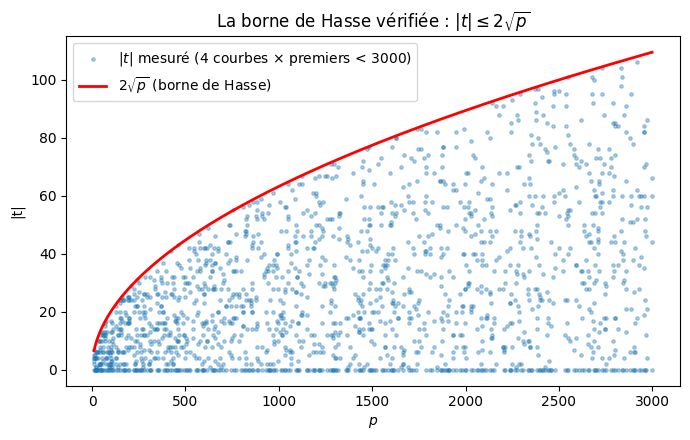

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ps = [d[0] for d in donnees]
ts = [d[1] for d in donnees]
ax.scatter(ps, ts, s=6, alpha=0.35, label="$|t|$ mesuré (4 courbes × premiers < 3000)")
borne = sorted(set(ps))
ax.plot(borne, [2 * math.sqrt(q) for q in borne], "r-", lw=2, label="$2\sqrt{p}$ (borne de Hasse)")
ax.set_xlabel("$p$"); ax.set_ylabel("|t|")
ax.set_title("La borne de Hasse vérifiée : $|t| \leq 2\sqrt{p}$")
ax.legend(); fig.tight_layout()
plt.show()

**Lecture** : le nuage grandit comme $\sqrt{p}$ et reste sous la courbe rouge — c'est le théorème, vu au lieu d'être énoncé. Pourquoi $\sqrt{p}$ ? Intuitivement, décider si $x^3+ax+b$ est un carré dans $\mathbb{F}_p$ ressemble à une suite de tirages aléatoires ; une somme de $p$ tels tirages fluctue en $\sqrt{p}$ (déviations quadratiques). Hasse (et Weil, généralisant) transforme cette intuition en théorème — et Serre, dans *A Course in Arithmetic* puis ses cours au Collège de France, en a fait l'un des fils directeurs de l'arithmétique des courbes.

## 5. La loi de groupe : la structure cachée

Ce n'est pas un sac de points : trois points alignés sur la courbe **somment à zéro**. La règle « corde et tangente » donne à $E(\mathbb{F}_p)$ une structure de groupe abélien — et c'est elle que la cryptographie sur courbes elliptiques exploite.

In [8]:
O = None  # point a l'infini, represente par None

def oppose(P, p):
    x, y = P
    return (x, (-y) % p)

def addition(P, Q, a, p):
    """Somme de deux points par cordes/tangentes, formules affines mod p."""
    if P is None: return Q
    if Q is None: return P
    x1, y1 = P; x2, y2 = Q
    if x1 == x2 and (y1 + y2) % p == 0:
        return None  # P + (-P) = O
    if P != Q:
        m = (y2 - y1) * pow(x2 - x1, -1, p) % p
    else:
        m = (3 * x1 * x1 + a) * pow(2 * y1, -1, p) % p
    x3 = (m * m - x1 - x2) % p
    y3 = (m * (x1 - x3) - y1) % p
    return (x3, y3)

# Verification sur la courbe y^2 = x^3 + 2x + 3 sur F_7 :
# generation du sous-groupe cyclique engendre par un point.
E = lambda x: (x*x*x + a*x + b) % p
P0 = points_affines(a, b, p)[0]
cycle, P = [], P0
while P is not None and P not in cycle:
    cycle.append(P)
    P = addition(P, P0, a, p)
print(f"Sous-groupe engendre par {P0} : ordre {len(cycle)}")
print(cycle[:6], "..." if len(cycle) > 6 else "")

Sous-groupe engendre par (2, 1) : ordre 5
[(2, 1), (3, 6), (6, 0), (3, 1), (2, 6)] 


Et la fonction zêta de la courbe, $Z(E/\mathbb{F}_p) = \frac{1 - tX + pX^2}{(1-X)(1-pX)}$, condense tout : $t$ la trace, $p+1-t$ le nombre de points, et les comptages sur toutes les extensions $\mathbb{F}_{p^r}$ — le point d'entrée de Weil vers les conjectures qui portent la borne.

In [9]:
# La trace determine les comptages sur les extensions :
# #E(F_{p^r}) = p^r + 1 - alpha^r - beta^r avec alpha*beta = p, alpha+beta = t.
from decimal import Decimal  # tenu simple : racines en complexes via nombres flottants
def comptage_extension(a, b, p, r):
    """#E(F_{p^r}) par la formule du polynome caracteristique de Frobenius."""
    t = trace_frobenius(a, b, p)
    disc = t * t - 4 * p
    ar, ai = t / 2, math.sqrt(max(-disc, 0) / 4)
    # alpha^r + beta^r = 2 * Re(alpha^r) car beta = conjugue
    mod = (ar * ar + ai * ai) ** (r / 2)
    arg = math.atan2(ai, ar)
    s = 2 * mod * math.cos(r * arg)
    return round(p ** r + 1 - s)

print("r :", [comptage_extension(a, b, p, r) for r in range(1, 5)])
print("verification r=1 :", comptage_extension(a, b, p, 1), "== ", nombre_points(a, b, p))

r : [6, 60, 378, 2400]
verification r=1 : 6 ==  6


## Exercices

### Exercice 1 — La non-singularité, testée

La fonction `est_lisse` ci-dessus encode $4a^3 + 27b^2 \neq 0$. Écrivez-la vous-même, puis trouvez **tous** les couples $(a, b)$ *singuliers* pour $p = 11$ — il y en a peu, et leur forme est instructive.

In [10]:
# Exercice 1 : non-singularite d'une courbe elliptique sur F_p.
def singuliers(p):
    """Liste des couples (a, b) de F_p x F_p tels que
    4a^3 + 27b^2 = 0 mod p (courbe singuliere)."""
    # Etape 1 : double boucle sur (a, b) dans range(p)
    # Indice : la condition est 4*a**3 + 27*b**2, modulo p
    # Etape 2 : collecter dans une liste et la renvoyer
    return None  # TODO etudiant

### Exercice 2 — La somme des caractères

Le lien profond entre carrés et trace : $\sum_{x \in \mathbb{F}_p} \chi(x^3 + ax + b) = -t$, où $\chi$ est le symbole de Legendre ($\chi(v) = 1$ si $v$ carré non nul, $-1$ sinon, $0$ si $v = 0$). Implémentez cette somme et vérifiez-la contre `trace_frobenius` sur quelques courbes.

In [11]:
# Exercice 2 : somme des caracteres de Legendre = -trace de Frobenius.
def caractere(v, p):
    """Symbole de Legendre chi(v) dans F_p : 1, -1 ou 0."""
    # Indice : pow(v, (p-1)//2, p) vaut 1, p-1 (c'est-a-dire -1) ou 0
    return None  # TODO etudiant

def somme_caracteres(a, b, p):
    """Somme sur x dans F_p de chi(x^3 + a*x + b). Doit valoir -t."""
    # Etape 1 : somme des caracteres(v, p) pour v = x^3+ax+b, x dans range(p)
    return None  # TODO etudiant

### Exercice 3 — La courbe extrême, par sondage déterminé

La borne $2\sqrt{p}$ est optimale : pour certains $(p, a, b)$, $|t|$ l'atteint presque. Balayer **tous** les $(a, b)$ pour $p = 10^4 + 7$ ferait $p^2 \approx 10^8$ courbes — hors de portée. Mais remarquez que `points_affines` cherche chaque racine carrée par **scan linéaire** : une **table des racines** construite une fois pour toutes en $O(p)$ rend le comptage de *chaque* courbe $O(p)$. Avec elle, sondez un **échantillon déterminé** — les couples $(a, b)$ multiples d'un pas fixe — et cherchez le couple lisse qui **maximise** le ratio $|t| / 2\sqrt{p}$, pour regarder comme il est proche de 1.

In [12]:
# Exercice 3 : la courbe la plus proche de la borne de Hasse, par sondage determine.
P_EXTREME = 10**4 + 7
PAS_SONDAGE = 211   # budget determine : (p/211)^2 = 48 x 48 = 2304 couples sondes

def racines_table(p):
    """Dictionnaire {v: y} ou v = y*y mod p et y est la plus petite racine.
    Cout O(p) -- a construire UNE fois. Avec elle, le nombre de points d'une
    courbe se calcule en O(p) au lieu du scan lineaire de points_affines."""
    # Etape 1 : pour y dans range(p), v = y*y % p est un carre
    # Etape 2 : ne garder que la plus petite racine de chaque carre (test d'absence)
    return None  # TODO etudiant

def pire_ratio_echantillon(p, pas):
    """Le ratio |t| / (2*sqrt(p)) maximal parmi les courbes y^2 = x^3 + ax + b
    lisses avec (a, b) multiples de pas, et le couple (a, b) qui l'atteint.
    Renvoie (ratio, a, b). Cout : O(p) pour la table, puis ~2300 courbes x O(p)."""
    # Etape 1 : racine = racines_table(p)
    # Etape 2 : boucle determinee sur a, b in range(0, p, pas) ; passer si non est_lisse(a, b, p)
    # Etape 3 : compter en O(p) : pour chaque x, v = (x^3 + a*x + b) % p vaut
    #           0 -> 1 point (y = 0), un carre non nul -> 2 points, sinon 0 ; + 1 pour l'infini
    # Etape 4 : t = p + 1 - nombre de points ; ratio = abs(t) / (2 * math.sqrt(p))
    # Indice : ~2300 courbes x O(p) ~ 2x10^7 operations -- quelques secondes
    return None  # TODO etudiant

## Conclusion

Ce qu'on a distillé :

- **un corps fini** se manipule avec trois opérations, et l'inverse existe toujours ;
- **compter des points** sur $y^2 = x^3+ax+b$ est un calcul élémentaire — aucune théorie nécessaire pour produire les données ;
- **la borne de Hasse** $|t| \leq 2\sqrt{p}$, énoncé profond, se *vérifie* sur 1701 courbes en quelques secondes — et le nuage $|t|$ contre $2\sqrt{p}$ en porte la vue intuitive (fluctuations en $\sqrt{p}$) ;
- la **trace de Frobenius** condense l'arithmétique de la courbe : comptages sur toutes les extensions via $\alpha + \beta = t$, $\alpha\beta = p$.

C'est le geste de Serre que cette série veut honorer : rendre l'objet **calculable** avant de le généraliser — les corps finis d'*A Course in Arithmetic* jusqu'à la fonction zêta.

## Ressources

- Jean-Pierre Serre, *A Course in Arithmetic*, Springer (ch. 1 : corps finis ; ch. 2 : formes modulaires — la borne sous-jacente est celle de Hasse-Weil).
- Conférence [Serre 100](https://serre100.sciencesconf.org/resource/page/id/1) (15-16 septembre 2026).
- EPIC [#16334 — Serre 100 : distillations exécutables](https://github.com/jsboige/CoursIA/issues/16334) — grains suivants : valeurs zêta multiples finies, caractères, Minkowski, zéros de fonctions L, et la voie décorrelée Serre–Grothendieck (Čech calculée, Yoneda calculé, `SerreMap.lean`).